In [1]:
import torch
import tqdm
import argparse
import functools
import numpy as np
import matplotlib.pyplot as plt

import os
import time
import copy
from regression.EmbeddingModule import FourierEmbedding, AdaptiveScale

from utils.utils_data import get_loader, load_data, read_cli_inference, find_files_with_extension, save_errors
from utils.utils_inference import append_unique_dicts_to_csv, extract_meaning_variables

from utils.utils_finetune_3d import initialize_FT3d
from regression.ViTModulev2 import MultiVit3_pl, MultiVit2_pl, Vit3_pl

import sys
torch.cuda.empty_cache()

/cluster/home/braonic/.local/lib/python3.11/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
config_reg = dict()

config_reg["which_data"] = "eul_riemann_kh3d"
config_reg["is_masked"] = False
config_reg["dt"] = 0.1
config_reg["max_num_time_steps"] = 1
config_reg["time_step_size"] = 14
config_reg["N_samples"] = 128
config_reg["ood_share"] = 0.0
config_reg["batch_size"] = 2
config_reg["is_ar"] = True
config_reg["is_time"] = True
config_reg["fix_input_to_time_step"] = None
config_reg["allowed_transitions"]= [1]
config_reg["workdir"] = None
config_reg["peak_lr"] = 1e-6
config_reg["end_lr"] = 1e-6
config_reg["warmup_epochs"] = 0
config_reg["epochs"] = 100
config_reg["N_train"] = 128
config_reg["s"] = 128
config_reg["device"] = "cuda"

arch = "/cluster/home/braonic/ood_generalization/configs/architectures_regression/config_basic_vit3_base.json"
config_reg_arch = load_data(arch)
device = "cuda"

In [7]:
shell = False

if shell:
    base_model_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/model/epoch=10-step=336550.ckpt"
    base_model = Vit3_pl(in_dim = 9, 
                    out_dim = 9,
                    loss_fn = None,
                    config_train = config_reg,
                    config_arch = config_reg_arch)

    checkpoint = torch.load(base_model_path, map_location = device)
    base_model.load_state_dict(checkpoint["state_dict"])
else:
    base_model_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus3d/PDEGYM_PLUS_3d_10ep_ViTB_regression/model/epoch=9-step=53320.ckpt"
    base_model = Vit3_pl(in_dim = 9, 
                    out_dim = 9,
                    loss_fn = None,
                    config_train = config_reg,
                    config_arch = config_reg_arch)
    patch_size = 4
    base_model  = initialize_FT3d(model = base_model, 
                    new_in_dim = 5, 
                    new_out_dim = 5, 
                    new_s = 64,
                    new_patch_size = patch_size,
                    dims = config_reg_arch["dims"],
                    latent_channels = config_reg_arch["latent_channels"],
                    init_new = False
                    )
    
    checkpoint = torch.load(base_model_path, map_location = device)
    base_model.load_state_dict(checkpoint["state_dict"])


8 1024


In [8]:
def load_model(path, config_reg, config_reg_arch, init_new = False, device = 'cuda'):
    
    print(path)
    ft_model_path = str(find_files_with_extension(path + "/model", "ckpt", [], is_pl = True)[0])

    ft_model = Vit3_pl(in_dim = 9, 
                    out_dim = 9,
                    loss_fn = None,
                    config_train = config_reg,
                    config_arch = config_reg_arch)

    patch_size = 4
    ft_model = initialize_FT3d(model = ft_model, 
                            new_in_dim = 5, 
                            new_out_dim = 5, 
                            new_s = 64,
                            new_patch_size = patch_size,
                            dims = config_reg_arch["dims"],
                            latent_channels = config_reg_arch["latent_channels"],
                            init_new = init_new
                            )

    print(ft_model_path)
    checkpoint = torch.load(ft_model_path, map_location = device)
    state_dict = checkpoint["state_dict"]

    if any("_orig_mod." in k for k in state_dict):
        state_dict = {k.replace("model._orig_mod.", "model."): v for k, v in state_dict.items()}
    if any("_orig_mod" in k for k in state_dict):
        state_dict = {k.replace("._orig_mod", ""): v for k, v in state_dict.items()}
    ft_model.load_state_dict(state_dict)
    
    return ft_model

In [12]:
R_diff = []
Rels = []

is_scratch = False

Ns = [1,2,4,8,16,32,64,128,256] 


for N in Ns:

    if not is_scratch:
        #path = f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann_kh3d/pre_schedule2ep_acc1_bs1_p16_ADDEMB_pdegym_plus3d_FT_eul_riemann_kh3d_non_native_{N}"
        path = f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus3d/PDEGYM_PLUS_3d_10ep_ViTB_regression/finetuned/eul_riemann_ellipse3d/post_pdegym_plus3d_FT_eul_riemann_ellipse3d_non_native_{N}"
    else:
        path = f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/eul_riemann_kh3d/ViT_BASE_scratch_125M/scaling_{N}"
    
    ft_model = load_model(path, config_reg, config_reg_arch, init_new=False)
    
    #if N == 1 and is_base:
    #base_model = copy.deepcopy(ft_model)    

    state_dict1 = base_model.state_dict()
    state_dict2 = ft_model.state_dict()

    rel_diffs = []

    for k in state_dict1:
        #if 'transformers.layers' in k and "weight" in k and "to_qkv" in k:
        #if 'patch_to_image' in k and "project" in k and "weight" in k:
        #if "embedding" in k and "linear.1" in k and "weight" in k:   
        #if "model.lift" in k and "weight" in k:   
        #if "model.project" in k and "weight" in k:   
        if "pe_proj" in k and "weight" in k:  
            print(k)
            param1 = state_dict1[k]
            param2 = state_dict2[k]
            denom = torch.sum(torch.abs(param1))
            if denom > 0:
                rel_diff = torch.sum(torch.abs(param1 - param2)) / denom
                rel_diffs.append(rel_diff.item())

    if rel_diffs:
        mean_rel_diff = sum(rel_diffs) / len(rel_diffs)
        print(f"Mean relative difference per MLP weight: {mean_rel_diff:.6f}", N, "Num found:",  len(rel_diffs))
    else:
        print("No matching parameters found.")

    Rels.append(rel_diffs)
    R_diff.append(mean_rel_diff)


/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus3d/PDEGYM_PLUS_3d_10ep_ViTB_regression/finetuned/eul_riemann_ellipse3d/post_pdegym_plus3d_FT_eul_riemann_ellipse3d_non_native_1
8 1024
/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus3d/PDEGYM_PLUS_3d_10ep_ViTB_regression/finetuned/eul_riemann_ellipse3d/post_pdegym_plus3d_FT_eul_riemann_ellipse3d_non_native_1/model/epoch=2-step=9.ckpt
model.embedding.pe_proj.weight
Mean relative difference per MLP weight: 0.040141 1 Num found: 1
/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus3d/PDEGYM_PLUS_3d_10ep_ViTB_regression/finetuned/eul_riemann_ellipse3d/post_pdegym_plus3d_FT_eul_riemann_ellipse3d_non_native_2
8 1024
/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus3d/PDEGYM_PLUS_3d_10ep_ViTB_regression/finetuned/eul_riemann_ellipse3d/post_pdegym_plus3d_FT_eul_riemann_ellipse3d_non_native_2/model/epoch=2-step=15.ckpt
model.embedding.pe_proj.weight
Mean relat

In [1]:
'''
RKH3d:

#R_diff = [0.005131, 0.009701, 0.012690, 0.019388, 0.089041, 0.122921, 0.176671, 0.187004, 0.189598] #qkv
#R_diff = [0.082049, 0.136083, 0.158181,  0.205838, 0.453235, 0.555576, 0.662810, 0.691444, 0.706798] #depatch
#R_diff = [0.005371, 0.001156, 0.007411, 0.004475, 0.089169, 0.141326, 0.222314, 0.218268, 0.227306] #patch
Ns =     [1,2,4,8, 16,32,64,128,256]
'''

'\nRKH3d:\n\n#R_diff = [0.005131, 0.009701, 0.012690, 0.019388, 0.089041, 0.122921, 0.176671, 0.187004, 0.189598] #qkv\n#R_diff = [0.082049, 0.136083, 0.158181,  0.205838, 0.453235, 0.555576, 0.662810, 0.691444, 0.706798] #depatch\n#R_diff = [0.005371, 0.001156, 0.007411, 0.004475, 0.089169, 0.141326, 0.222314, 0.218268, 0.227306] #patch\nNs =     [1,2,4,8, 16,32,64,128,256]\n'

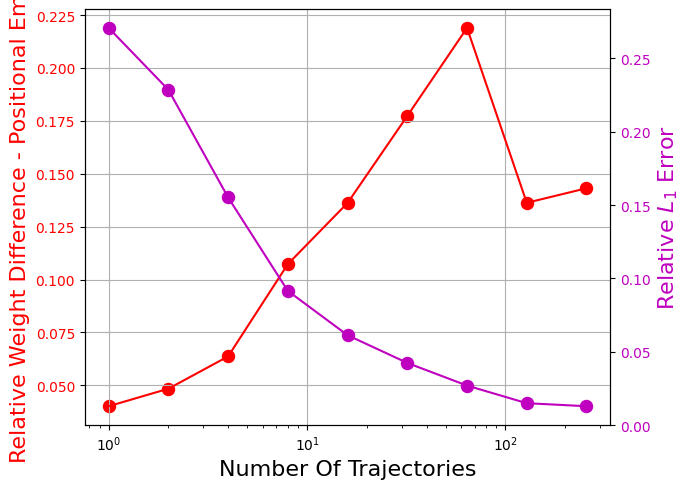

In [23]:
save_fig = True
which = "eul_riemann_ellipse3d"
# which = eul_riemann_ellipse3d 
weight = "pe_proj" #depatch #patch #lift #project #pe_proj


if weight == "qkv": 
    if "ellipse" in which:
        R_diff= [0.000988, 0.001328, 0.003654, 0.010388, 0.014717, 0.020469, 0.027847, 0.021478, 0.024504]
    elif "kh" in which:
        R_diff = [0.005131, 0.009701, 0.012690, 0.019388, 0.089041, 0.122921, 0.176671, 0.187004, 0.189598]
elif weight == "depatch":
    if "ellipse" in which:
        R_diff = [0.008884, 0.011235, 0.018954, 0.050975, 0.078081, 0.115386, 0.162776, 0.107783, 0.121698]
    elif "kh" in which:
        R_diff = [0.082049, 0.136083, 0.158181,  0.205838, 0.453235, 0.555576, 0.662810, 0.691444, 0.706798]
elif weight == "patch":
    if "ellipse" in which:
        R_diff = [0.001412, 0.001662, 0.003574, 0.009601, 0.013979, 0.020591, 0.027826, 0.016882, 0.018545]
    elif "kh" in which:
        R_diff = [0.005371, 0.001156, 0.007411, 0.004475, 0.089169, 0.141326, 0.222314, 0.218268, 0.227306]
elif weight == "lift":
    if "ellipse" in which:
        R_diff = [0.005532, 0.005397, 0.010369, 0.032268, 0.051182, 0.061299, 0.083349, 0.053253, 0.055481]
    else:
        R_diff = []
elif weight == "project":
    if "ellipse" in which:
        R_diff = [0.019127, 0.026163, 0.032879, 0.106708, 0.135108, 0.143714, 0.189874, 0.117966, 0.123152]
    else:
        R_diff = []
elif weight == "pe_proj":
    if "ellipse" in which:
        R_diff = [0.040141, 0.048414, 0.063684, 0.107308, 0.136206, 0.177325, 0.218933, 0.136282, 0.143147]
    else:
        R_diff = []

if "ellipse" in which:
    Err =  [0.27071, 0.2285290, 0.155167, 0.091462, 0.0612701, 0.0423690, 0.026933, 0.014923, 0.0128759 ]
    color = "m"
elif "kh" in which:
    Err = [0.479653, 0.4752751, 0.471664, 0.4531312, 0.4201424022, 0.13504476, 0.087615680, 0.076798, 0.0668097 ]
    color = "blue"


Ns = [1,2,4,8, 16,32,64,128,256]


fig, ax1 = plt.subplots(figsize=(7, 5))

# First axis (left)
ax1.scatter(Ns, R_diff, s=75, color="red", label="R_diff")
ax1.plot(Ns, R_diff, color="red")

if weight == "qkv":
    ax1.set_ylabel("Relative Weight Difference - QKV", fontsize=16, color="red")
elif weight == "depatch":
    ax1.set_ylabel("Relative Weight Difference - Depatch", fontsize=16, color="red")
elif weight == "patch":
    ax1.set_ylabel("Relative Weight Difference - Patch", fontsize=16, color="red")
elif weight == "lift":
    ax1.set_ylabel("Relative Weight Difference - Lift", fontsize=16, color="red")
elif weight == "project":
    ax1.set_ylabel("Relative Weight Difference - Project", fontsize=16, color="red")
elif weight == "pe_proj":
    ax1.set_ylabel("Relative Weight Difference - Positional Emb.", fontsize=16, color="red")


ax1.set_xlabel("Number Of Trajectories", fontsize=16)
ax1.set_xscale("log")
ax1.grid(True)
ax1.tick_params(axis='y', labelcolor='red')

# Second axis (right)
ax2 = ax1.twinx()
ax2.scatter(Ns, Err, s=75, color=color, label="Err")
ax2.plot(Ns, Err, color=color)
ax2.set_ylabel("Relative $L_1$ Error", fontsize=16, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.tight_layout()

if save_fig:
    plt.savefig(f"Figures/{which}/{which}_mlp_param_difference_ft_vs_base_{weight}_weights.pdf", dpi = 400)
    plt.savefig(f"Figures/{which}/{which}_mlp_param_difference_ft_vs_base_{weight}_weights.png", dpi = 400)

plt.show()


In [133]:
import pandas as pd

def read_csv(csv_path, col_name, dl = 55):
    df = pd.read_csv(csv_path)

    # Extract the desired column
    if col_name in df.columns:
        data = np.array(df[col_name].dropna().to_numpy())
    

    D = []
    for i in range(150):
        x = data[i*dl : (i+1)*dl]
        D.append(np.mean(x))
    
    return np.array(D)

def get_color(model):
    if model == "pdegym":
        return "red"
    if model == "pdegym2":
        return "dodgerblue"
    elif model == "pdegym_mini":
        return "green"
    elif model == "pdegym_plus":
        return "blue"
    elif model == "pdegym_giga":
        return "orange"
    elif model == "poseidon":
        return "purple"
    elif model == "poseidon_l":
        return "magenta"
    elif model == "scratch":
        return "sienna"
    elif model == "scratch_b":
        return "darkorange"
    else:
        return "black"

In [123]:
# Path to your CSV file
csv_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann3d/pdegym_plus_FT_eul_riemann3d_non_native_64/wandb_export_2025-07-28T16_29_28.011+02_00.csv"
col_name = "pdegym_plus_3d_64_eul_riemann3d_non_native_pdegym_plus - train/loss_avg"
train_loss_ft = read_csv(csv_path, col_name)


csv_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann3d/pdegym_plus_FT_eul_riemann3d_non_native_64/wandb_export_2025-07-28T16_35_55.650+02_00.csv"
col_name = "pdegym_plus_3d_64_eul_riemann3d_non_native_pdegym_plus - val/mean_val_all"
val_loss_ft = read_csv(csv_path, col_name, dl = 1)

csv_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann3d/pdegym_plus_FT_eul_riemann3d_non_native_64/wandb_export_2025-07-28T17_33_04.166+02_00.csv"
col_name = "scaling_64_reg_eul_riemann3d - train/loss_avg"
train_loss_base = read_csv(csv_path, col_name)

csv_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann3d/pdegym_plus_FT_eul_riemann3d_non_native_64/wandb_export_2025-07-28T17_37_40.806+02_00.csv"
col_name = "scaling_64_reg_eul_riemann3d - val/mean_val_all"
val_loss_base = read_csv(csv_path, col_name, dl = 1)

csv_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann3d/pdegym_plus_FT_eul_riemann3d_non_native_64/wandb_export_2025-07-28T18_14_44.737+02_00.csv"
col_name = "scaling_64_reg_eul_riemann3d - train/loss_avg"
train_loss_base_s = read_csv(csv_path, col_name, dl = 25)

csv_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/eul_riemann3d/pdegym_plus_FT_eul_riemann3d_non_native_64/wandb_export_2025-07-28T18_16_36.334+02_00.csv"
col_name = "scaling_64_reg_eul_riemann3d - val/mean_val_all"
val_loss_base_s = read_csv(csv_path, col_name, dl = 1)


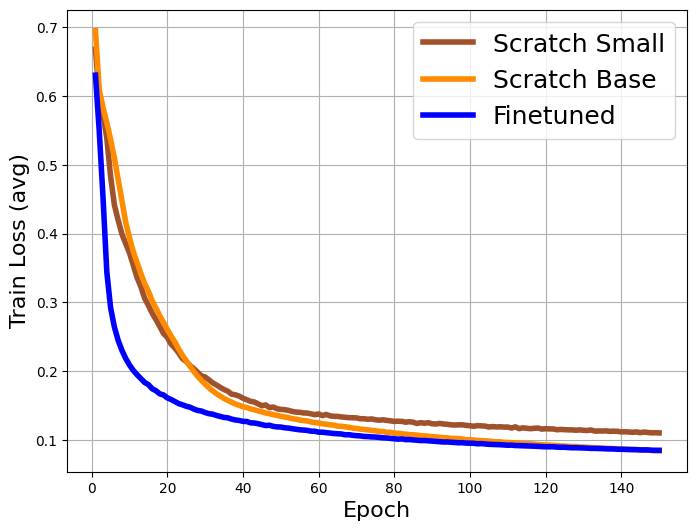

In [135]:
save_fig = True

fig, ax = plt.subplots(figsize=(8, 6))

linewidth = 4
plt.plot(np.arange(1,151), train_loss_base_s, linewidth = linewidth, label = "Scratch Small", color = get_color("scratch"))
plt.plot(np.arange(1,151), train_loss_base, linewidth = linewidth, label = "Scratch Base", color =  get_color("scratch_b"))
plt.plot(np.arange(1,151), train_loss_ft, linewidth = linewidth, label = "Finetuned", color =  get_color("pdegym_plus"))

plt.legend(fontsize = 18)
plt.ylabel("Train Loss (avg)", fontsize = 16)
plt.xlabel("Epoch", fontsize = 16)
plt.grid(True)
#plt.yscale("log")

if save_fig:
    plt.savefig(f"Figures/eul_riemann3d/eul_riemann3d_base_vs_ft_train_loss.pdf", dpi = 400)
    plt.savefig(f"Figures/eul_riemann3d/eul_riemann3d_base_vs_ft_train_loss.png", dpi = 400)
plt.show()



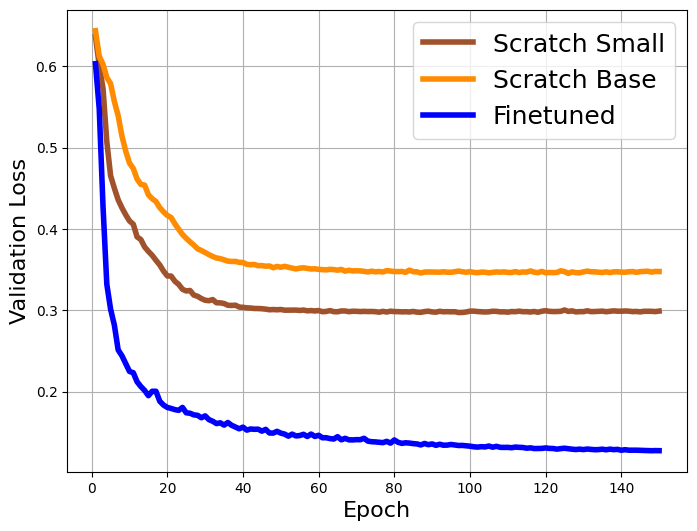

In [136]:
fig, ax = plt.subplots(figsize=(8, 6))

plt.plot(np.arange(1,151), val_loss_base_s, linewidth = linewidth, label = "Scratch Small", color =  get_color("scratch"))
plt.plot(np.arange(1,151), val_loss_base, linewidth = linewidth, label = "Scratch Base", color =  get_color("scratch_b"))
plt.plot(np.arange(1,151), val_loss_ft, linewidth = linewidth, label = "Finetuned", color = get_color("pdegym_plus"))

plt.legend(fontsize = 18)
plt.ylabel("Validation Loss", fontsize = 16)
plt.xlabel("Epoch", fontsize = 16)
plt.grid(True)
#plt.yscale("log")

if save_fig:
    plt.savefig(f"Figures/eul_riemann3d/eul_riemann3d_base_vs_ft_val_loss.pdf", dpi = 400)
    plt.savefig(f"Figures/eul_riemann3d/eul_riemann3d_base_vs_ft_val_loss.png", dpi = 400)

plt.show()

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>


In [63]:
def load_data(folder, exact_file):
    if exact_file == "spectral_stats":
        return np.load(f"{folder}/{exact_file}.npz")
    elif exact_file == "metrics_results":
        with open(f"{folder}/metrics_results.json") as f:
            data = json.load(f)
        print(data)
        print(" ")
        f.close()
        return data
    elif exact_file == "physical_stats":
        return np.load(f"{folder}/{exact_file}.npz")

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import json


G = [0.0, 1.0]
gt = None
Gs = []
exact_file = "spectral_stats"

"""
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_eul_riemann_curved_"
"""

prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_10k_FT_ns_shear_gencfd_non_native_10000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"

for i, guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    print("Guidance is ", guidance)
    data = load_data(folder, exact_file)
    
    if exact_file == "spectral_stats":
        if i == 0 :
            gt = np.mean(data['spectrum_gt'], axis = 0)
        Gs.append(np.mean(data['spectrum_gen'], axis = 0))


Guidance is  0.0
Guidance is  1.0


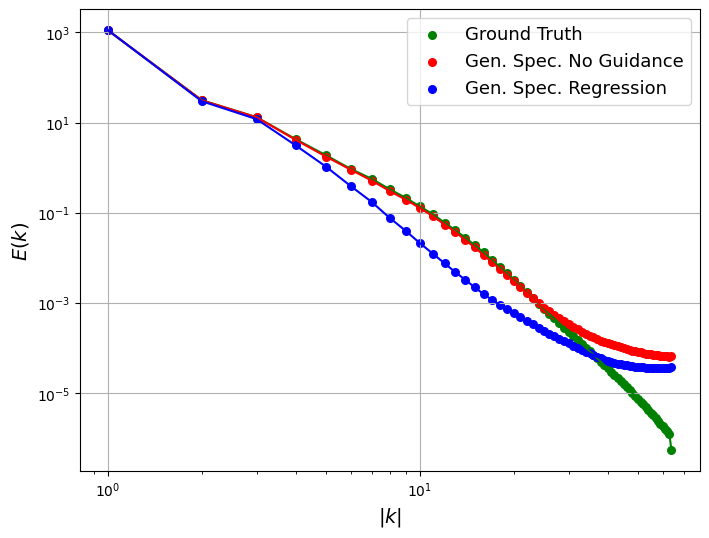

In [121]:
save_fig = True

fig, ax = plt.subplots(figsize=(8, 6))

plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), gt[1:,0], label = "Ground Truth",color = "green", s =30)#, axis = 0))
plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), gt[1:,0],color = "green")#, axis = 0))

for i,g in enumerate(G):

    if g == 0.0:
        color = "red"
        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], label = "Gen. Spec. No Guidance", color = "red", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0],color = "red")#, axis = 0))
    elif g == 1.0:
        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], label = "Gen. Spec. Regression", color = "blue", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], color = "blue")#, axis = 0))
    else:
        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], label = f"Gen. Spec. $g = {g}$", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0])#, axis = 0))

plt.grid(True)
plt.xlabel(r'$|k|$',fontsize = 14)
plt.ylabel(r'$E(k)$',fontsize = 14)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize = 13)

if save_fig:
    if "eul_riemann_curved" in prefix or "eul_riemann_curved" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_spectral_estimated_spectra.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_spectral_estimated_spectra.png", dpi = 400)
    if "ns_shear" in prefix or "ns_shear" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_spectral_estimated_spectra.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_spectral_estimated_spectra.png", dpi = 400)


In [95]:

prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_10k_FT_ns_shear_gencfd_non_native_10000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"
channels = 2
G = [0.0, 0.2, 0.5, 1.0]
W = np.zeros((channels, len(G)))

"""
G = [0.0, 0.1, 0.15, 0.2, 0.25, 0.4, 0.5, 0.75, 1.0]
W = np.zeros((4, len(G)))
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_eul_riemann_curved_"
"""
for i,guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    with open(f"{folder}/metrics_results.json") as f:
        M = json.load(f)
    
    for j in range(channels):
        wass = M['wasserstein_distance'][f"wass_{j}"]
        W[j,i] = wass


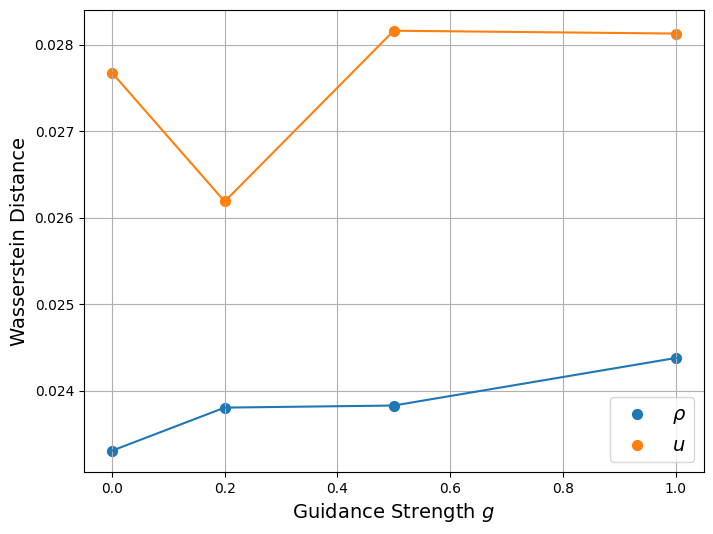

In [96]:
save_fig = False

fig, ax = plt.subplots(figsize=(8, 6))

plt.scatter(G,W[0], s = 50, label = r'$\rho$')
plt.plot(G,W[0])
plt.scatter(G,W[1], s = 50, label = r'$u$')
plt.plot(G,W[1])
plt.grid()

plt.xlabel(r'Guidance Strength $g$',fontsize = 14)
plt.ylabel(r'Wasserstein Distance',fontsize = 14)

plt.legend(fontsize = 14)

if save_fig:
    plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_wass_distance.pdf", dpi = 400)
    plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_wass_distance.png", dpi = 400)



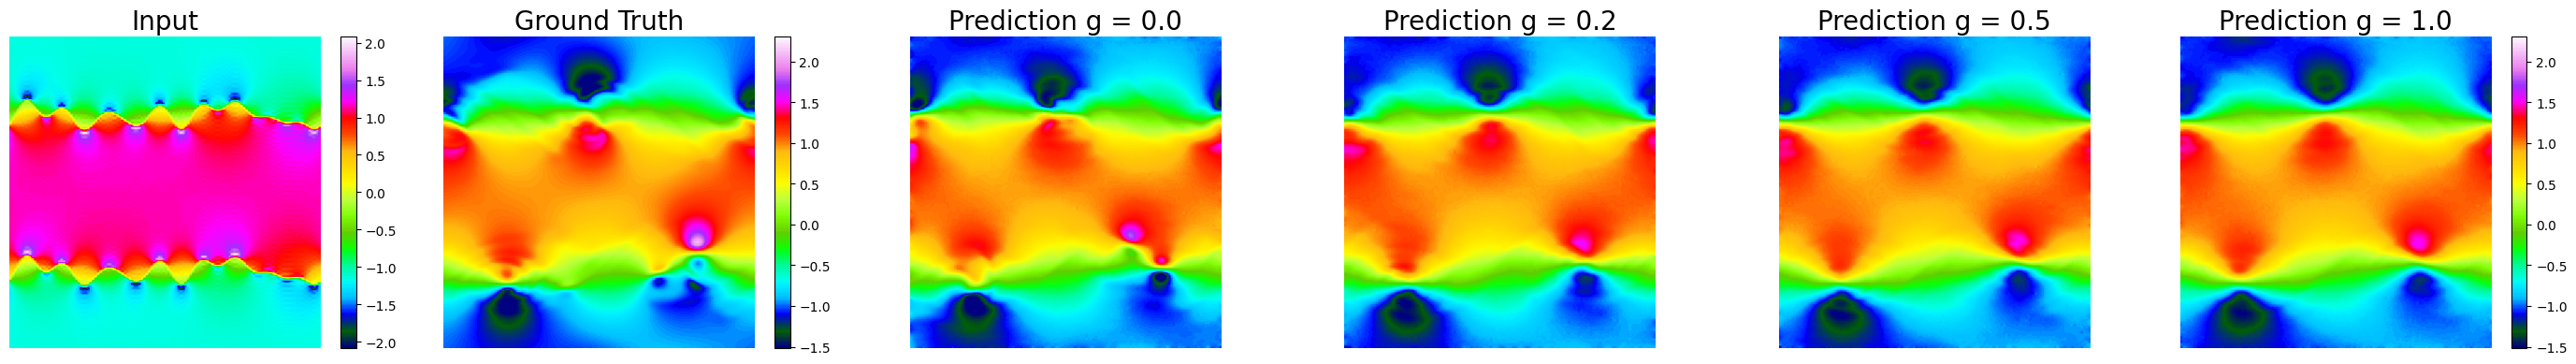

In [126]:
import numpy as np
import matplotlib.pyplot as plt

'''
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_eul_riemann_curved_"
'''

prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_10k_FT_ns_shear_gencfd_non_native_10000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"

G = [0.0, 0.2, 0.5, 1.0]
out = None
inp = None
preds = []
id = 17

save_fig = True

W = np.zeros((4, len(G)))
for i,guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    if i == 0:
        inp = np.load(f"{folder}/sample_{id}_steps_1_1.0_inp.npy")
        out = np.load(f"{folder}/sample_{id}_steps_1_1.0_out.npy")
    preds.append(np.load(f"{folder}/sample_{id}_steps_1_1.0_pred.npy"))



c = 0
c_gt = 1

vmin = np.min(out[c_gt])*0.9
vmax = np.max(out[c_gt])*1.1

fig, axes = plt.subplots(1, len(G)+2, figsize=((len(G)+2)*4 + 4, 4))
cmap = "gist_ncar"

im1 = axes[0].imshow(inp[c_gt], cmap=cmap)#, vmin = vmin, vmax = vmax)
axes[0].set_title("Input", fontsize = 20)
axes[0].axis('off')

# Show each image
im2 = axes[1].imshow(out[c_gt], cmap=cmap, vmin = vmin, vmax = vmax)
axes[1].set_title('Ground Truth', fontsize = 20)
axes[1].axis('off')

# Show each image
for (i,g) in enumerate(G):
    im = axes[2+i].imshow(preds[i][c], cmap=cmap, vmin = vmin, vmax = vmax)
    axes[2+i].set_title(f"Prediction g = {g}", fontsize = 20)
    axes[2+i].axis('off')

fig.colorbar(im1,orientation='vertical')
fig.colorbar(im2,orientation='vertical')
fig.colorbar(im,orientation='vertical')
plt.tight_layout()
    

if save_fig:
    if "eul_riemann_curved" in prefix or "eul_riemann_curved" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_PREDs_sample_{id}_channel_{c}.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_PREDs_sample_{id}_channel_{c}.png", dpi = 400)
    if "ns_shear" in prefix or "ns_shear" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_PREDs_sample_{id}_channel_{c}.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_PREDs_sample_{id}_channel_{c}.png", dpi = 400)

plt.show()





NpzFile '/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_10k_FT_ns_shear_gencfd_non_native_10000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_ns_shear_gencfd_/physical_stats.npz' with keys: mean_gen, mean_gt, std_gen, std_gt, gen_samples...
0.014896139
0.040550087


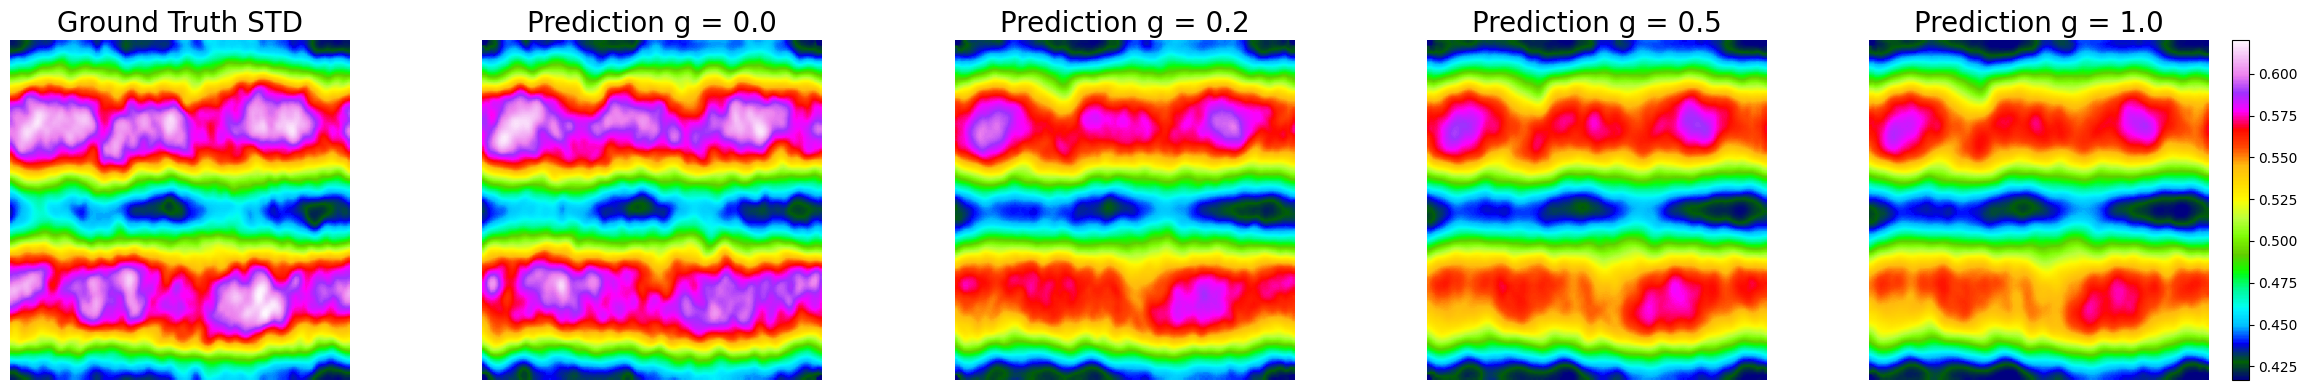

In [106]:
save_fig = False

which = "STD"
G = [0.0, 0.2, 0.5, 1.0]
gt_mean = None
gt_std = None
means = []
stds = []
c = 1
for i, guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    data = load_data(folder, "physical_stats")
    if i == 0:
        print(data)
        gt_mean = data['mean_gt'][c]
        gt_std = data["std_gt"][c]
    means.append(data['mean_gen'][c])
    stds.append(data['std_gen'][c])

if which == "MEAN":
    gt = gt_mean
    pred = means
elif which == "STD":
    gt = gt_std
    pred = stds


print(np.mean(abs(gt - pred[0]))/np.mean(abs(gt)))
print(np.mean(abs(gt - pred[-1]))/np.mean(abs(gt)))

vmin = np.min(gt)
vmax = np.max(gt)

fig, axes = plt.subplots(1, len(G)+1, figsize=((len(G)+1)*4 + 4, 4))
cmap = "gist_ncar"

axes[0].imshow(gt, cmap=cmap)#, vmin = vmin, vmax = vmax)
axes[0].set_title(f"Ground Truth {which}", fontsize = 20)
axes[0].axis('off')

# Show each image
for (i,g) in enumerate(G):
    im = axes[1+i].imshow(pred[i], cmap=cmap, vmin = vmin, vmax = vmax)
    axes[1+i].set_title(f"Prediction g = {g}", fontsize = 20)
    axes[1+i].axis('off')

fig.colorbar(im,orientation='vertical')
plt.tight_layout()


if save_fig:
    plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_STATISTICS_{which}_channel_{c}.pdf", dpi = 400)
    plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_STATISTICS_{which}_channel_{c}.png", dpi = 400)

plt.show()





<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>


In [1]:
import xarray as xr

path = '/cluster/work/math/braonic/data/ns_shear2d_gencfd/ns_shear2d_gencfd_macro_micro.nc'

ds = xr.open_dataset(path)
print(ds)


<xarray.Dataset> Size: 4GB
Dimensions:  (macro: 10, micro: 1000, time: 2, x: 128, y: 128, c: 3)
Dimensions without coordinates: macro, micro, time, x, y, c
Data variables:
    data     (macro, micro, time, x, y, c) float32 4GB ...


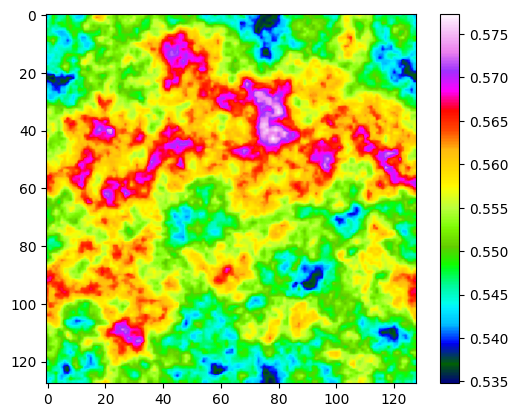

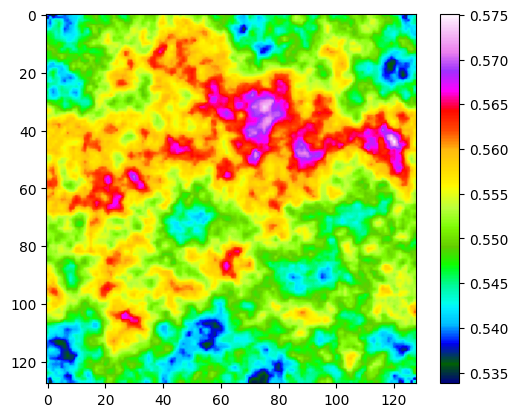

In [27]:
#vmin = np.min(a["mean_gt"][0])
plt.imshow(a["mean_gt"][3], cmap = "gist_ncar")
plt.colorbar()
plt.show()
plt.imshow(a["mean_gen"][3], cmap = "gist_ncar")
plt.colorbar()

In [7]:
#!/usr/bin/env python3
# List variables in a NetCDF file using netCDF4

from netCDF4 import Dataset
import sys
from textwrap import indent

def print_var(vname, var, prefix=""):
    dims = "(" + ", ".join(var.dimensions) + ")"
    dtype = str(var.dtype)
    try:
        shape = tuple(var.shape)
    except Exception:
        shape = "?"
    attrs_to_show = ["long_name", "standard_name", "units", "description"]
    shown = {k: getattr(var, k) for k in attrs_to_show if hasattr(var, k)}
    attr_str = ", ".join(f'{k}="{v}"' for k, v in shown.items())
    line = f"{prefix}{vname} {dims}  dtype={dtype}  shape={shape}"
    if attr_str:
        line += f"  [{attr_str}]"
    print(line)

def print_group(grp, path="/"):
    print(f"\n# Group: {path}")
    if grp.dimensions:
        print("Dimensions:")
        for dname, dim in grp.dimensions.items():
            size = len(dim) if not dim.isunlimited() else "UNLIMITED"
            print(f"  {dname} = {size}")
    else:
        print("Dimensions: (none)")

    if grp.variables:
        print("Variables:")
        for vname, var in grp.variables.items():
            print_var(vname, var, prefix="  ")
    else:
        print("Variables: (none)")

    # Recurse into subgroups
    for gname, subgrp in grp.groups.items():
        subpath = path.rstrip("/") + "/" + gname
        print_group(subgrp, subpath)

def main(nc_path):
    with Dataset(nc_path, "r") as ds:
        # Global attributes summary (optional)
        print(f"File: {nc_path}")
        if ds.ncattrs():
            print("Global attributes:")
            for a in ds.ncattrs():
                # Avoid dumping extremely long attrs
                val = getattr(ds, a)
                s = str(val)
                if len(s) > 200:
                    s = s[:200] + "…"
                print(indent(f"{a}: {s}", "  "))
        
        print_group(ds, "/")

#path = "/cluster/work/math/camlab-data/data/diffusion_project/macro_micro_in_distribution_nothing_N128.nc"
path = "/cluster/work/math/camlab-data/data/diffusion_project/macro_micro_id_2d.nc"
path = "/cluster/work/math/camlab-data/data/diffusion_project/ddsl_fast_nothing_128_tr2.nc"
main(path)


File: /cluster/work/math/camlab-data/data/diffusion_project/ddsl_fast_nothing_128_tr2.nc

# Group: /
Dimensions:
  member = 99000
  time = 2
  x = 128
  y = 128
  c = 3
Variables:
  data (member, time, x, y, c)  dtype=float32  shape=(99000, 2, 128, 128, 3)


In [11]:
import xarray as xr
import matplotlib.pyplot as plt

# Path to your NetCDF file
path = "/cluster/work/math/camlab-data/data/diffusion_project/ddsl_fast_nothing_128_tr2.nc"
ds = xr.open_dataset(path)



In [29]:
print(ds)

<xarray.Dataset> Size: 39GB
Dimensions:  (member: 99000, time: 2, x: 128, y: 128, c: 3)
Dimensions without coordinates: member, time, x, y, c
Data variables:
    data     (member, time, x, y, c) float32 39GB ...


In [35]:
u = ds["data"][:500,:,:,:,0]
v = ds["data"][:500,:,:,:,1]


In [36]:
import numpy as np

print(np.mean(u), np.std(u))
print(np.mean(v), np.std(v))


<xarray.DataArray 'data' ()> Size: 4B
array(-7.450581e-12, dtype=float32) <xarray.DataArray 'data' ()> Size: 4B
array(0.8701995, dtype=float32)
<xarray.DataArray 'data' ()> Size: 4B
array(5.4278192e-12, dtype=float32) <xarray.DataArray 'data' ()> Size: 4B
array(0.38360977, dtype=float32)


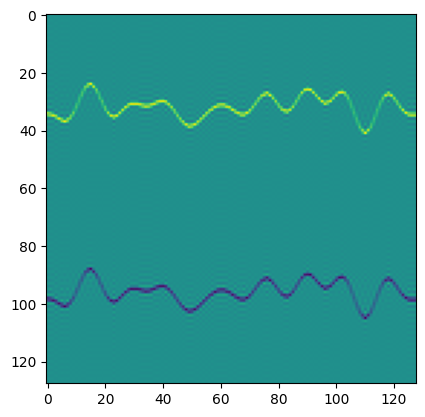

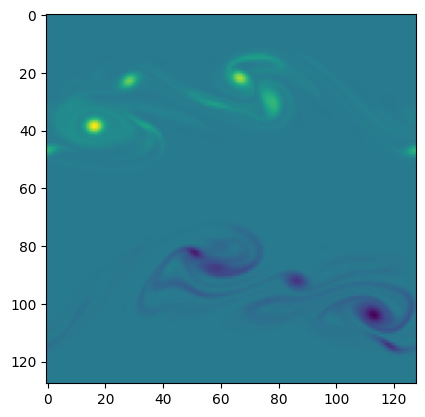

In [27]:
plt.imshow(ds["data"][98000,0,:,:,2])
plt.show()
plt.imshow(ds["data"][110,1,:,:,2])

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X = np.load("/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data/samples_steps_1_1.0_128_out.npy")
Y = np.load("/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data/samples_steps_1_1.0_128_pred.npy")



In [9]:
X.shape

(128, 9, 128, 128)

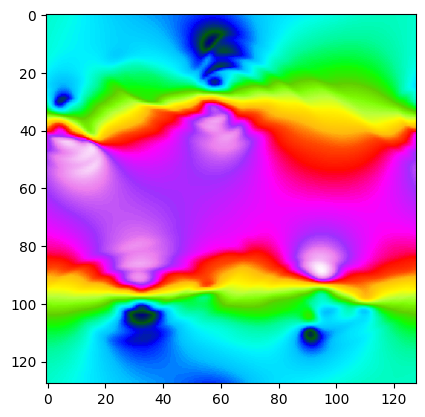

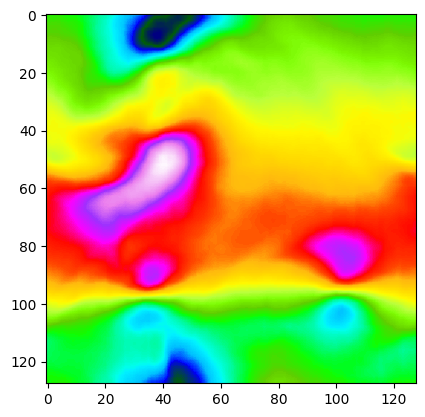

In [10]:
plt.imshow(X[6,1], cmap = "gist_ncar")
plt.show()
plt.imshow(Y[6,1], cmap = "gist_ncar")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data/ns_shear_gencfd_pdegym_plus_pred_128.nc"
ds = xr.open_dataset(path)

path2 = "/cluster/work/math/braonic/data/ns_shear2d_gencfd/ne_shear2d_gencfd.nc"
ds2 = xr.open_dataset(path2)
print(ds)

path_poseidon = "/cluster/work/math/camlab-data/synthetic/IEU_2D_DDSLTracer.nc"
dsp = xr.open_dataset(path_poseidon)
print(dsp)


<xarray.Dataset> Size: 17MB
Dimensions:       (member: 128, time: 1, x: 128, y: 128)
Coordinates:
  * member        (member) int32 512B 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
Dimensions without coordinates: time, x, y
Data variables:
    time_i        (time) int32 4B ...
    time_j        (time) int32 4B ...
    u             (member, time, x, y) float32 8MB ...
    v             (member, time, x, y) float32 8MB ...
    written_mask  (member) int8 128B ...
Attributes:
    description:  PDEGym+ predictions
    note:         C order [rho,u,v,p]; time indices stored in time_i/time_j  ...
    created_by:   streaming-writer
    layout:       variables: rho,u,v,p with dims (member,time,x,y) -- OR just...
<xarray.Dataset> Size: 83GB
Dimensions:  (member: 20000, time: 21, x: 128, y: 128)
Coordinates:
  * member   (member) int64 160kB 0 1 2 3 4 5 ... 19995 19996 19997 19998 19999
  * time     (time) float32 84B 0.0 0.05 0.1 0.15 0.2 ... 0.8 0.85 0.9 0.95 1.0
  * x        (x) float32 512B 0.0

(99000, 2, 128, 128, 3) (128, 1, 128, 128)


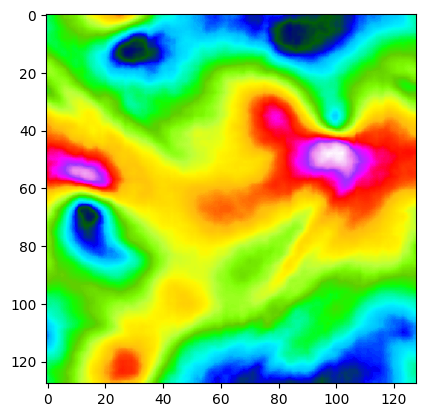

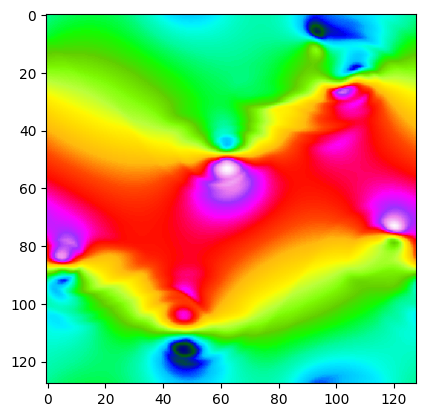

In [2]:
print(ds2["data"].shape, ds["u"].shape)
n = 1

pred = ds["u"][n,0]
out = ds2["data"][n,1,:,:,0]

plt.imshow(pred, cmap = "gist_ncar", vmin = np.min(pred),  vmax = np.max(pred))
plt.show()
plt.imshow(out, cmap = "gist_ncar")

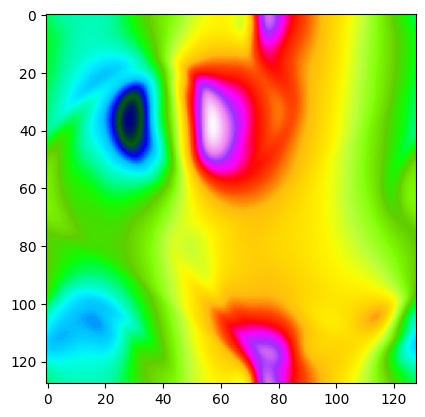

In [3]:
plt.imshow(dsp["u"][0,20], cmap = "gist_ncar")

In [14]:
from netCDF4 import Dataset

nc_path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/eul_ns3d_mix1/TURBO_MASK_scratch_Base_10ep_8gpus_bs3_4acc_10000/predictions_ns_shear3d_generated_data/ns_shear3d_pdegym_plus_pred_10.nc"

# Open file read-only
ds = Dataset(nc_path, mode="r")
print("Opened:", nc_path)


# --- Dimensions ---
print("\n=== Dimensions ===")
for name, dim in ds.dimensions.items():
    print(f"{name}: size={len(dim)}")

# --- Variables ---
print("\n=== Variables ===")
for name, var in ds.variables.items():
    # var.shape is a tuple; var.datatype is dtype
    print(f"{name}: dims={var.dimensions}, shape={var.shape}, dtype={var.datatype}")

# --- Global attributes ---
print("\n=== Global attributes ===")
for attr in ds.ncattrs():
    print(f"{attr} = {getattr(ds, attr)}")

# If you want to quickly inspect one variable, e.g. first few values:
var_name = None  # e.g. "u", "v", "rho" etc.
if var_name is not None and var_name in ds.variables:
    v = ds.variables[var_name]
    print(f"\nSample from variable '{var_name}':")
    # Slices chosen to avoid loading everything into memory
    print(v[0, ...])  # adjust slicing as needed




Opened: /cluster/work/math/braonic/TrainedModels/OOD_Generalization/eul_ns3d_mix1/TURBO_MASK_scratch_Base_10ep_8gpus_bs3_4acc_10000/predictions_ns_shear3d_generated_data/ns_shear3d_pdegym_plus_pred_10.nc

=== Dimensions ===
member: size=10
time: size=10
x: size=64
y: size=64
z: size=64

=== Variables ===
member: dims=('member',), shape=(10,), dtype=int32
time_i: dims=('time',), shape=(10,), dtype=int32
time_j: dims=('time',), shape=(10,), dtype=int32
w: dims=('member', 'time', 'x', 'y', 'z'), shape=(10, 10, 64, 64, 64), dtype=float32
u: dims=('member', 'time', 'x', 'y', 'z'), shape=(10, 10, 64, 64, 64), dtype=float32
v: dims=('member', 'time', 'x', 'y', 'z'), shape=(10, 10, 64, 64, 64), dtype=float32
written_mask: dims=('member',), shape=(10,), dtype=int8

=== Global attributes ===
description = PDEGym+ predictions
note = C mapping: 2=[u,v]; 3=[u,v,w]; 4=[rho,u,v,p]; 5=[rho,u,v,w,p]. Spatial dims: 2D=(x,y) or 3D=(x,y,z). Time indices stored in time_i/time_j.
created_by = streaming-writ

In [15]:
import matplotlib.pyplot as plt
import numpy as np

ds["u"][3,0,0]

masked_array(
  data=[[-1.5858108, -1.5838336, -1.5824784, ..., -1.5797242, -1.5812875,
         -1.5859417],
        [-1.5890352, -1.5868301, -1.5865431, ..., -1.5834844, -1.5843349,
         -1.5880367],
        [-1.5883234, -1.5875365, -1.5867679, ..., -1.5842435, -1.5847389,
         -1.588689 ],
        ...,
        [-1.5859035, -1.5834042, -1.5818839, ..., -1.5806502, -1.5805252,
         -1.5843226],
        [-1.5858611, -1.5840883, -1.5829302, ..., -1.5813905, -1.5817684,
         -1.5862857],
        [-1.5875684, -1.5881126, -1.5895563, ..., -1.5853106, -1.5879527,
         -1.5880884]],
  mask=False,
  fill_value=1e+20,
  dtype=float32)

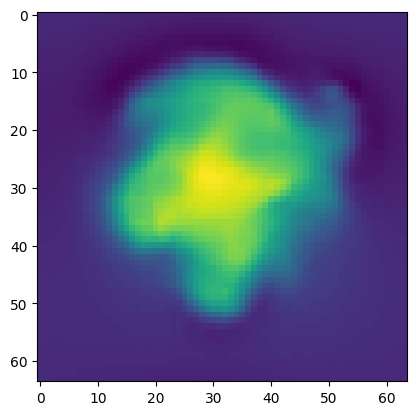

In [16]:
plt.imshow(ds['u'][3,2,32])

In [13]:
ds['w'].shape

(10000, 10, 64, 64, 64)